In [1]:
%matplotlib inline
from __future__ import division
import matplotlib
import numpy as np
from pylab import *
from mpl_toolkits.mplot3d import Axes3D
import h5py
import os
import re
matplotlib.rcParams.update({"axes.formatter.limits": (-4,4)})
plotStyles={"markersize":20,"markeredgewidth":3.0,"linewidth":3.0}
stepStyles={"markersize":20,"markeredgewidth":3.0,"linewidth":3.0,"where":"post"}
scatterStyles={"s":100,"marker":"x","linewidth":3.0}
np.seterr(divide='ignore',invalid='ignore')
pass

In [2]:
def addOrderParameter(filename, id, type, speciesIDs, speciesCoefficients):
    print "Adding order parameters to %s"%filename
    fp = h5py.File(filename, "r+")
    if "OrderParameters" not in fp.keys():
        opg = fp.create_group("/OrderParameters/%07d"%id)
        opg.attrs.create("ID", id, dtype=np.uint32)
        opg.attrs.create("Type", type, dtype=np.uint32)
        d1=opg.create_dataset("SpeciesIDs", (len(speciesIDs),), dtype=np.uint32)
        d1[:]=np.array(speciesIDs)
        d2=opg.create_dataset("SpeciesCoefficients", (len(speciesIDs),), dtype=double)
        d2[:]=np.array(speciesCoefficients)
    else:
        print "ERROR: file already has order parameters"
    fp.close()
    


### Execute with time limit

In [118]:
%%bash
dirname=data/1
filename=${dirname}/rdme_bimolecular.lm
mkdir -p ${dirname}
rm -f ${filename} && lm_sbml_import ${filename} rdme_bimolecular.sbml
DYLD_LIBRARY_PATH=/usr/local/cuda/lib lm_setdm ${filename} numberReactions=2 numberSpecies=3 numberSiteTypes=1 "latticeSize=[5,6,7]" latticeSpacing=1e-6 particlesPerSite=16 "DiffusionMatrix(0,0,:)=[1e-10,1e-10,1e-10]" "ReactionLocationMatrix=[1,1]";
lm_setp ${filename} maxTime=1e3 writeInterval=1e3 latticeWriteInterval=1e3

lm_sbml_import v2016.01.20 build 1
Copyright (C) 2008-2012 Luthey-Schulten Group, University of Illinois at Urbana-Champaign.
Copyright (C) 2012-2016 Roberts Group, Johns Hopkins University.


Done.
lm_setdm v2012.12-JHU build by eroberts on barkeri at 2014-08-19 17:43:24
Copyright (C) 2008-2012 Luthey-Schulten Group,
University of Illinois at Urbana-Champaign.

Setting diffusion model in simulation file data/1/rdme_bimolecular.lm:
numberReactions=2
numberSpecies=3
numberSiteTypes=1
latticeSize=[5,6,7]
latticeSpacing=1.000000e-06
particlesPerSite=16
DiffusionMatrix(0)=1.000000e-10
DiffusionMatrix(1)=1.000000e-10
DiffusionMatrix(2)=1.000000e-10
ReactionLocationMatrix(0)=1
ReactionLocationMatrix(1)=1
Placed 100 particles of type 0 in 100 attempts.
Placed 100 particles of type 1 in 100 attempts.
Placed 0 particles of type 2 in 0 attempts.
2016-01-11 11:19:59) Debug: Closing file data/1/rdme_bimolecular.lm, 0 open objects remaining.
Done.
lm_setp v2016.01.20 build 1
Copyright (C) 2008-2012

In [121]:
%%bash
dirname=data/1
filename=${dirname}/rdme_bimolecular.lm
echo "Execute the following command in `pwd`:"
echo lmes -r 1-1 -f ${filename} -gr 0 -c 2 -sl lm::rdme::NextSubvolumeSolver
#> ${filename}.log
echo "Finished."

Execute the following command in /Users/eroberts/Work/Lab/Git/LatticeMicrobesES/regression/rdme_bimolecular:
lmes -r 1-1 -f data/1/rdme_bimolecular.lm -gr 0 -c 2 -sl lm::rdme::NextSubvolumeSolver
Finished.


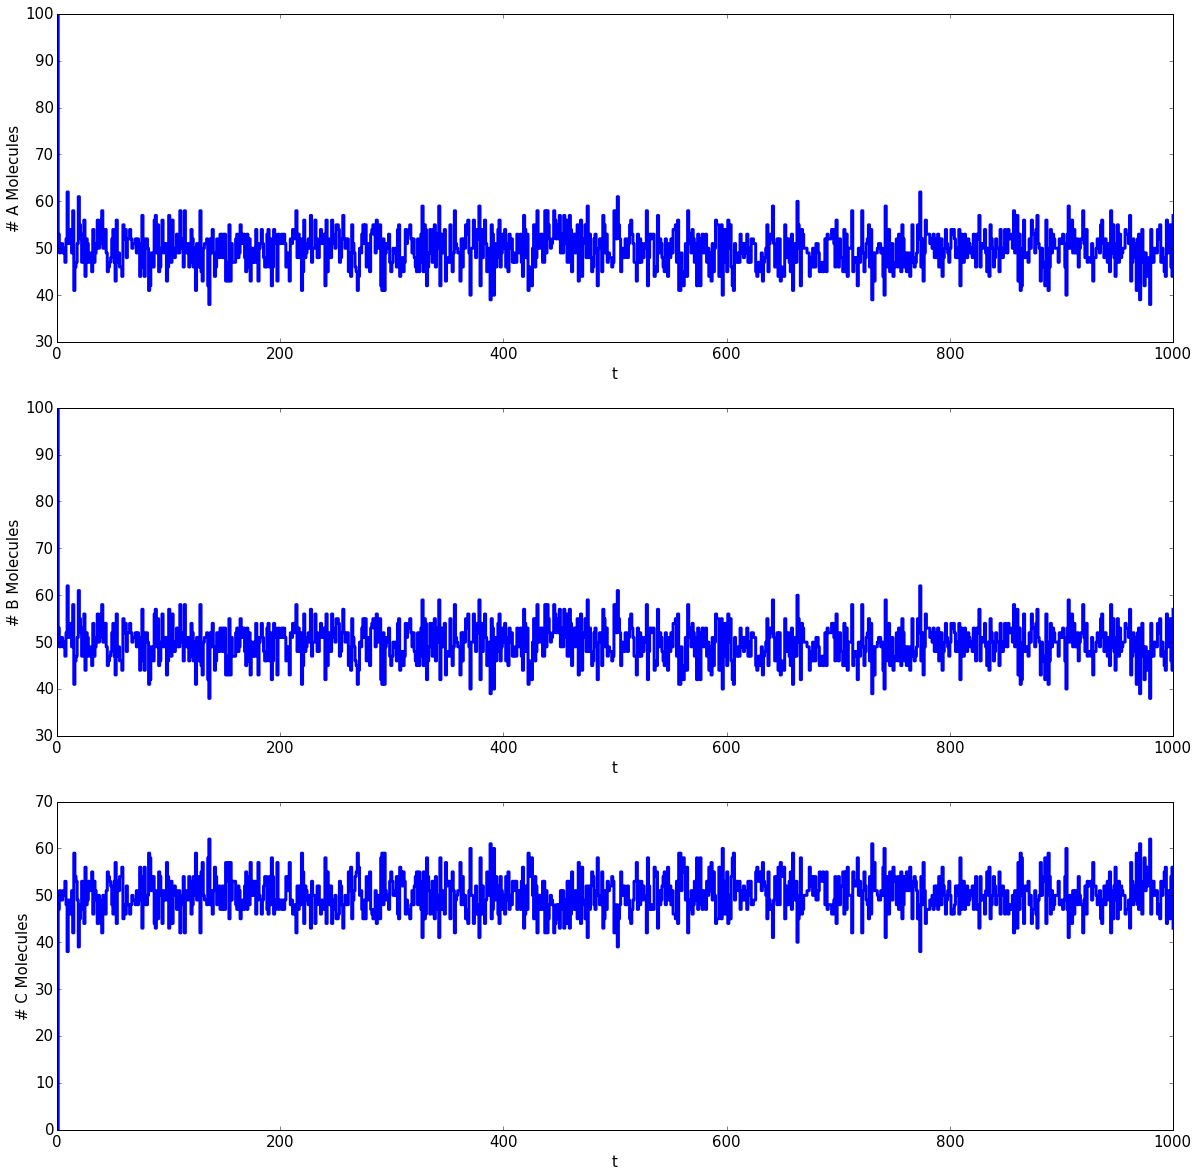

In [93]:
# Plot the time series for a few replicates.
dirname="data/1"
filename="%s/rdme_bimolecular.lm"%dirname
fp = h5py.File(filename, "r")
matplotlib.rcParams.update({'font.size': 15, "figure.figsize": (20,20)})
for replicate in (1,):
    counts=np.array(fp["/Simulations/%07d/SpeciesCounts"%replicate], dtype=double)
    times=np.array(fp["/Simulations/%07d/SpeciesCountTimes"%replicate], dtype=double)
    plt.subplot(3,1,1)
    step(times,counts[:,0], **stepStyles)
    xlabel('t'); ylabel('# A Molecules')
    plt.subplot(3,1,2)
    step(times,counts[:,1], **stepStyles)
    xlabel('t'); ylabel('# B Molecules')
    plt.subplot(3,1,3)
    step(times,counts[:,2], **stepStyles)
    xlabel('t'); ylabel('# C Molecules')
fp.close()
pass

Averaging from 10010 time points: min=0.224, mean=0.238 (exp=000), max=0.248


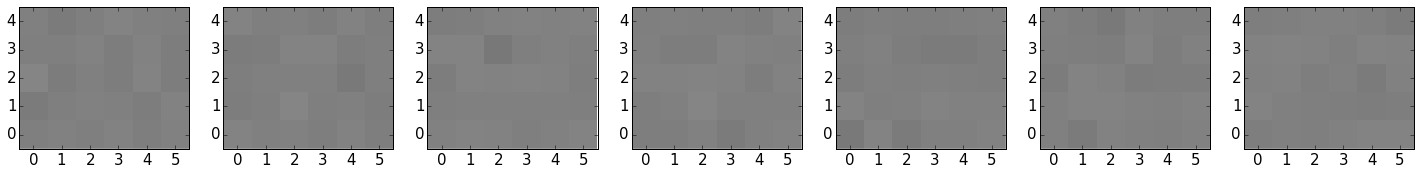

In [99]:
# Plot the probability density of species C.
dirname="data/1"
filename="%s/rdme_bimolecular.lm"%dirname
fp = h5py.File(filename, "r")
replicates=fp["/Simulations"].keys()
k=0
mSim=None
vSim=None
times=None
count = 0
lc = np.zeros((5,6,7), dtype=double)
for replicate in replicates:
    lattices=fp["/Simulations/%s/Lattice"%replicate].keys()
    for lattice in lattices:
        lfull = np.array(fp["/Simulations/%s/Lattice/%s"%(replicate,lattice)], dtype=np.uint8)
        lc += np.sum(lfull==2+1,3)
        count += 1
lc /= count
print "Averaging from %d time points: min=%0.3f, mean=%0.3f (exp=%0.3d), max=%0.3f"%(count,np.min(lc),np.mean(lc),50.0/210.0,np.max(lc))
matplotlib.rcParams.update({'font.size': 15, "figure.figsize": (25,25)})
for i in range(0,lc.shape[2]):
    plt.subplot(1,lc.shape[2],i+1)
    plt.imshow(lc[:,:,i], cmap=plt.cm.gray, origin='lower', interpolation="none", vmin=0.0, vmax=(50.0/210.0)*2.0)
pass

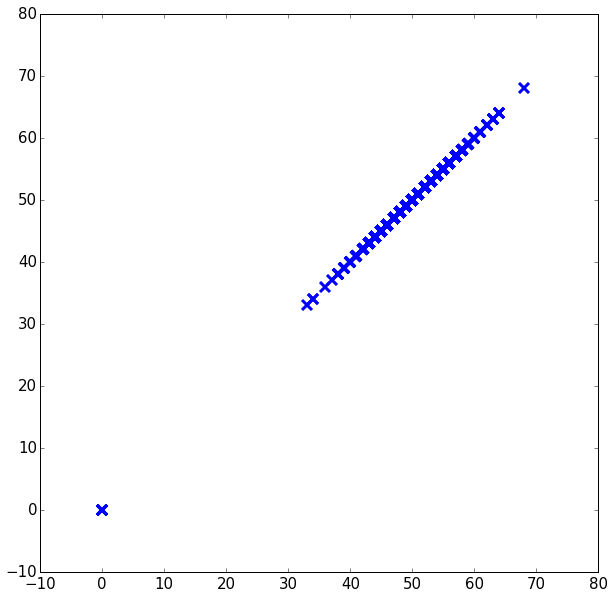

In [102]:
# Compare species counts and lattice counts for species C.
dirname="data/1"
filename="%s/rdme_bimolecular.lm"%dirname
fp = h5py.File(filename, "r")
replicates=fp["/Simulations"].keys()
xs=[]
ys=[]
for replicate in replicates:
    counts=np.array(fp["/Simulations/%s/SpeciesCounts"%replicate], dtype=double)
    for i in range(0,counts.shape[0]):
        xs.append(counts[i,2])
    lattices=fp["/Simulations/%s/Lattice"%replicate].keys()
    for lattice in lattices:
        lfull = np.array(fp["/Simulations/%s/Lattice/%s"%(replicate,lattice)], dtype=np.uint8)
        ys.append(np.sum(lfull==2+1))
matplotlib.rcParams.update({'font.size': 15, "figure.figsize": (10,10)})
plt.scatter(xs,ys, **scatterStyles)
pass

### Performance comparison

In [112]:
%%bash
dirname=data/perf.99.latest
filename=${dirname}/rdme_bimolecular.lm
mkdir -p ${dirname}
rm -f ${filename} && lm_sbml_import ${filename} rdme_bimolecular.sbml
DYLD_LIBRARY_PATH=/usr/local/cuda/lib lm_setdm ${filename} numberReactions=2 numberSpecies=3 numberSiteTypes=1 "latticeSize=[5,6,7]" latticeSpacing=1e-6 particlesPerSite=16 "DiffusionMatrix(0,0,:)=[1e-10,1e-10,1e-10]" "ReactionLocationMatrix=[1,1]";
lm_setp ${filename} maxTime=5e2 writeInterval=5e1 latticeWriteInterval=5e1
echo "Execute the following command in `pwd`:"
echo 'for replicate in `seq -f "%g" 0 10`; do'
echo "echo Running \${replicate};"
#echo "hostname=\`hostname\`"
#echo "lmesPrefix=/share/git/LatticeMicrobesES/build/"
#echo "hostname=barkeri"
#echo "lmesPrefix="
echo "hostname=marcc"
echo "lmesPrefix=/home-2/erober32@jhu.edu/share/git/LatticeMicrobesES/build-icc/"
#echo "hostname=marcc-gcc"
#echo "lmesPrefix=/home-2/erober32@jhu.edu/usr/bin/"
echo "\${lmesPrefix}lmes -r 1-8 -f ${filename} -c 2 -gr 0 -ff null -sl lm::rdme::NextSubvolumeSolver| tee ${filename}.\${hostname}.\${replicate}.log";
echo 'done;'

lm_sbml_import v2016.01.20 build 1
Copyright (C) 2008-2012 Luthey-Schulten Group, University of Illinois at Urbana-Champaign.
Copyright (C) 2012-2016 Roberts Group, Johns Hopkins University.


Done.
lm_setdm v2012.12-JHU build by eroberts on barkeri at 2014-08-19 17:43:24
Copyright (C) 2008-2012 Luthey-Schulten Group,
University of Illinois at Urbana-Champaign.

Setting diffusion model in simulation file data/perf.99.latest/rdme_bimolecular.lm:
numberReactions=2
numberSpecies=3
numberSiteTypes=1
latticeSize=[5,6,7]
latticeSpacing=1.000000e-06
particlesPerSite=16
DiffusionMatrix(0)=1.000000e-10
DiffusionMatrix(1)=1.000000e-10
DiffusionMatrix(2)=1.000000e-10
ReactionLocationMatrix(0)=1
ReactionLocationMatrix(1)=1
Placed 100 particles of type 0 in 100 attempts.
Placed 100 particles of type 1 in 100 attempts.
Placed 0 particles of type 2 in 0 attempts.
2016-01-11 11:08:58) Debug: Closing file data/perf.99.latest/rdme_bimolecular.lm, 0 open objects remaining.
Done.
lm_setp v2016.01.20 build

In [122]:
# Extract the timing data.
datadir="data"
timingData={}
testNumberMap={}
regex0 = re.compile("perf\.(\d+).(\S+)")
regex1 = re.compile("\.lm\.([^\.]+)\.(\d+)\.log")
regex2 = re.compile("Finished .+ seconds \((\S+) steps/second\)")
for dirname in os.listdir(datadir):
    testName = None
    m = regex0.search(dirname)
    if m != None:
        testNumber = m.group(1)
        testName = m.group(2)
        testNumberMap[testNumber] = testName
    if testName is not None:
        for logname in os.listdir(datadir+"/"+dirname):
            m = regex1.search(logname)
            if m != None:
                host=m.group(1)
                replicate=int(m.group(2))
                with open(datadir+"/"+dirname+"/"+logname) as f:
                    for line in f:
                        m = regex2.search(line)
                        if m != None:
                            if host not in timingData:
                                timingData[host]={}
                            if testName not in timingData[host]:
                                timingData[host][testName]=[]
                            timingData[host][testName].append(double(m.group(1)))
                            break

[1899636.3636363635, 1962090.9090909092, 1759181.8181818181, 1918181.8181818181, 2264454.5454545454]


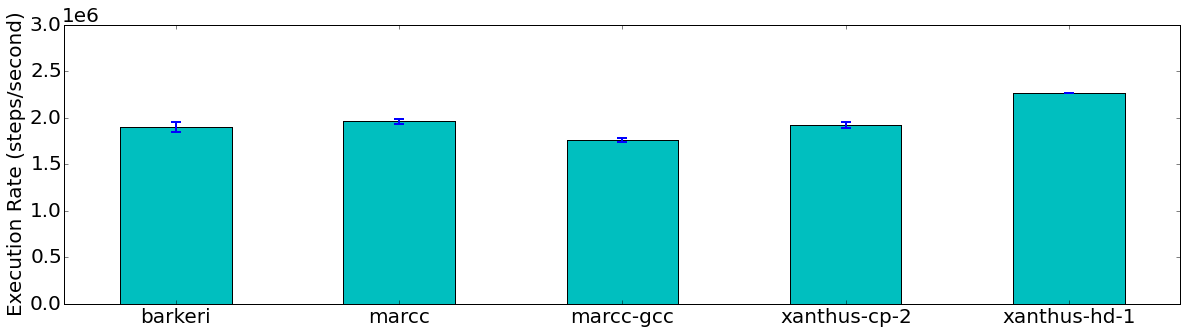

In [124]:
# Plot the latest timing data.
matplotlib.rcParams.update({'font.size': 20, "figure.figsize": (20,5)})
hosts = timingData.keys()
hosts.sort()
times=[]
timesErr=[]
for host in hosts:
    if "latest" in timingData[host]:
        times.append(mean(timingData[host]['latest']))
        timesErr.append(std(timingData[host]['latest']))
print times
plt.bar(arange(0,len(hosts))+0.25,times,width=0.5,yerr=timesErr, color='c', error_kw={"elinewidth":2,"capsize":5,"capthick":2})
plt.ylabel('Execution Rate (steps/second)')
plt.xticks(arange(0,len(hosts))+0.5, hosts)
plt.ylim([0,3e6])
pass

In [ ]:
# Plot the previous timing data.
matplotlib.rcParams.update({'font.size': 20, "figure.figsize": (30,25)})
hosts = timingData.keys()
hosts.sort()
testNumbers = testNumberMap.keys()
testNumbers.sort()
for i,host in enumerate(hosts):
    times=[]
    timesErr=[]
    testNames=[]
    for testNumber in testNumbers:
        testName = testNumberMap[testNumber]
        if testName in timingData[host]:
            times.append(mean(timingData[host][testName]))
            timesErr.append(std(timingData[host][testName]))
            testNames.append(testName)
    plt.subplot(len(hosts),1,i+1)
    plt.errorbar(arange(0,len(testNames))+0.5,times,linewidth=2,yerr=timesErr,elinewidth=2,capsize=5,capthick=2)
    plt.ylabel('Execution Rate (steps/second)')
    plt.xticks(arange(0,len(testNames))+0.5, testNames)
    plt.xlim([0,len(testNames)]); plt.ylim([1e7,4e7])
    plt.title(host)
    print times
pass